In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('/content/Telco_Customer_Churn_Cleaned.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [5]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [name, accuracy]
    )

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)

results_df

,Model,Accuracy
0,Logistic Regression,0.804549
1,Decision Tree,0.712864
2,Random Forest,0.785359
3,Gradient Boosting,0.795309


In [6]:
results_df.sort_values(
    by='Accuracy',
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy
0,Logistic Regression,0.804549
3,Gradient Boosting,0.795309
2,Random Forest,0.785359
1,Decision Tree,0.712864


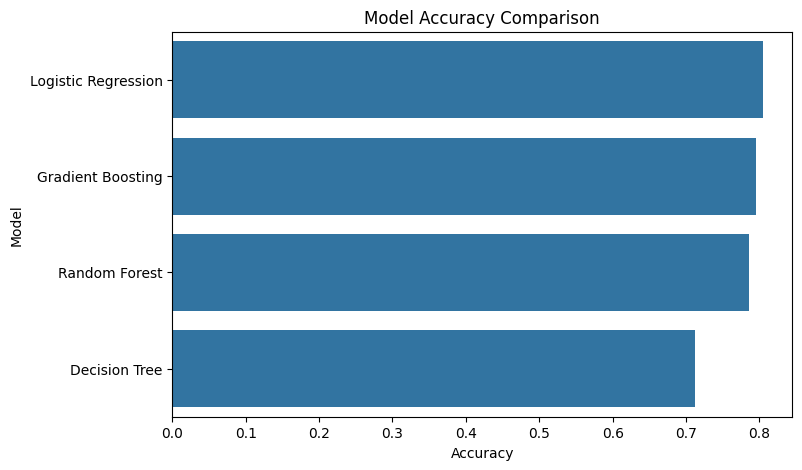

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model'
)

plt.title("Model Accuracy Comparison")

plt.show()

In [9]:
best_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.4f}")

Cross-validation scores: [0.80241649 0.81236674 0.79089616 0.81009957 0.8029872 ]
Mean cross-validation score: 0.8038
